In [1]:
%load_ext autoreload
%autoreload 1
%aimport rectificacion, disparidad, profundidad, aruco

In [2]:
import numpy as np 
import cv2 as cv
import matplotlib.pyplot as plt

# LIMPIEZA DE ARCHIVOS

In [3]:
import os, glob, shutil

# Directorios a limpiar
dirs_to_clean = {
    "data/pointcloud": "*.ply",           # Nubes individuales
    "data/pointcloud/world_pnp": "*.ply", # Nubes transformadas
}

print("=== LIMPIEZA DE ARCHIVOS ANTIGUOS ===\n")

for dir_path, pattern in dirs_to_clean.items():
    if not os.path.exists(dir_path):
        print(f"⚠️  {dir_path} no existe, salteando...")
        continue
    
    files = glob.glob(os.path.join(dir_path, pattern))
    
    if len(files) == 0:
        print(f"✓ {dir_path} ya está vacío")
    else:
        print(f"🗑️  Borrando {len(files)} archivos en {dir_path}/")
        for f in files:
            try:
                os.remove(f)
                print(f"   ✓ {os.path.basename(f)}")
            except Exception as e:
                print(f"   ✗ Error borrando {os.path.basename(f)}: {e}")
        print(f"   → Borrados {len(files)} archivos\n")

# Opcional: borrar también final_merged.ply si existe
merged = "data/pointcloud/final_merged.ply"
if os.path.exists(merged):
    os.remove(merged)
    print(f"🗑️  Borrado: {merged}")

print("\n✅ Limpieza completa. Ahora regenerá las nubes:")
print("   1. profundidad.calc_profundidad()")
print("   2. Loop de PnP con detect_pose_homography")
print("   3. Fusión final")

=== LIMPIEZA DE ARCHIVOS ANTIGUOS ===

🗑️  Borrando 21 archivos en data/pointcloud/
   ✓ 001_left_0_rect.ply
   ✓ 019_left_7_rect.ply
   ✓ 013_left_2_rect.ply
   ✓ 021_left_9_rect.ply
   ✓ 014_left_20_rect.ply
   ✓ 003_left_10_rect.ply
   ✓ 005_left_12_rect.ply
   ✓ 020_left_8_rect.ply
   ✓ 011_left_18_rect.ply
   ✓ 015_left_3_rect.ply
   ✓ 018_left_6_rect.ply
   ✓ 009_left_16_rect.ply
   ✓ 006_left_13_rect.ply
   ✓ 008_left_15_rect.ply
   ✓ 012_left_19_rect.ply
   ✓ 016_left_4_rect.ply
   ✓ 002_left_1_rect.ply
   ✓ 007_left_14_rect.ply
   ✓ 004_left_11_rect.ply
   ✓ 017_left_5_rect.ply
   ✓ 010_left_17_rect.ply
   → Borrados 21 archivos

🗑️  Borrando 21 archivos en data/pointcloud/world_pnp/
   ✓ 007_left_14_rect_world.ply
   ✓ 002_left_1_rect_world.ply
   ✓ 004_left_11_rect_world.ply
   ✓ 009_left_16_rect_world.ply
   ✓ 016_left_4_rect_world.ply
   ✓ 005_left_12_rect_world.ply
   ✓ 008_left_15_rect_world.ply
   ✓ 006_left_13_rect_world.ply
   ✓ 003_left_10_rect_world.ply
   ✓ 018_lef

# RECTIFICACION

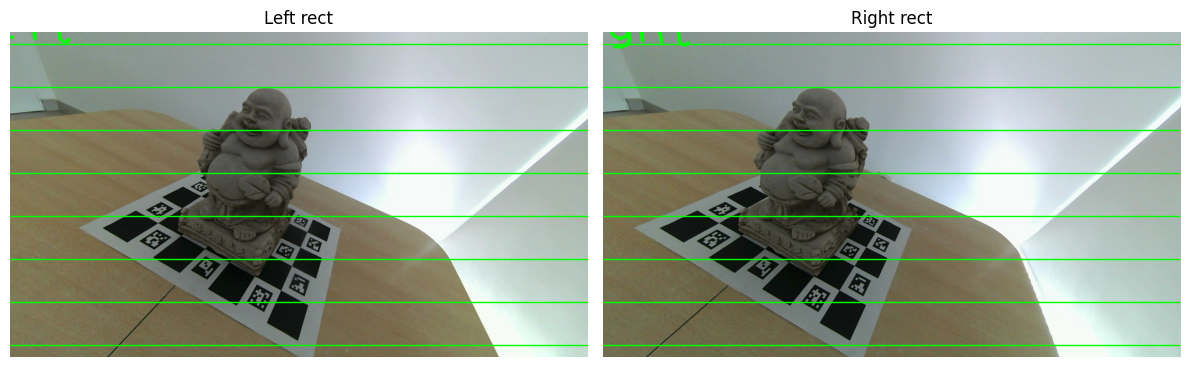

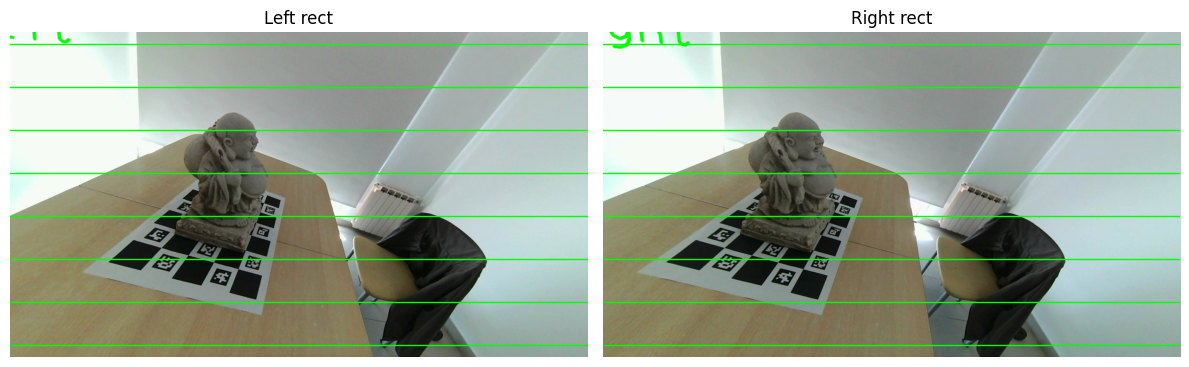

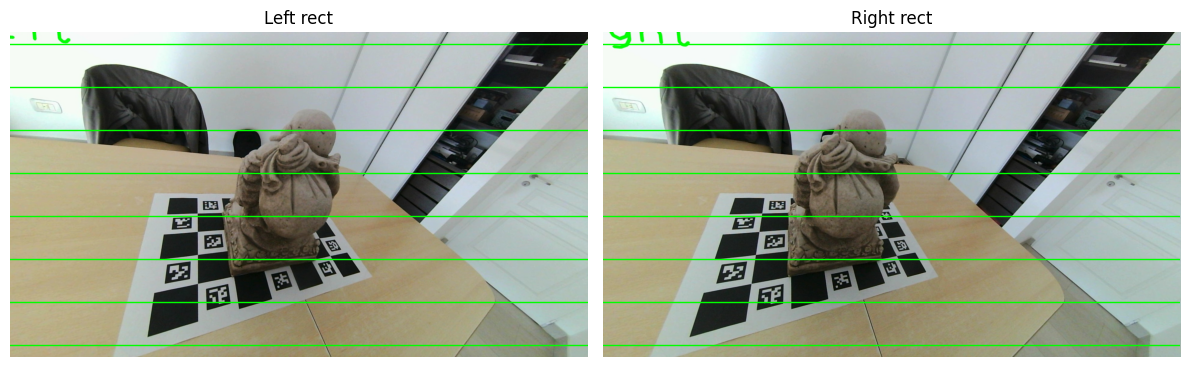

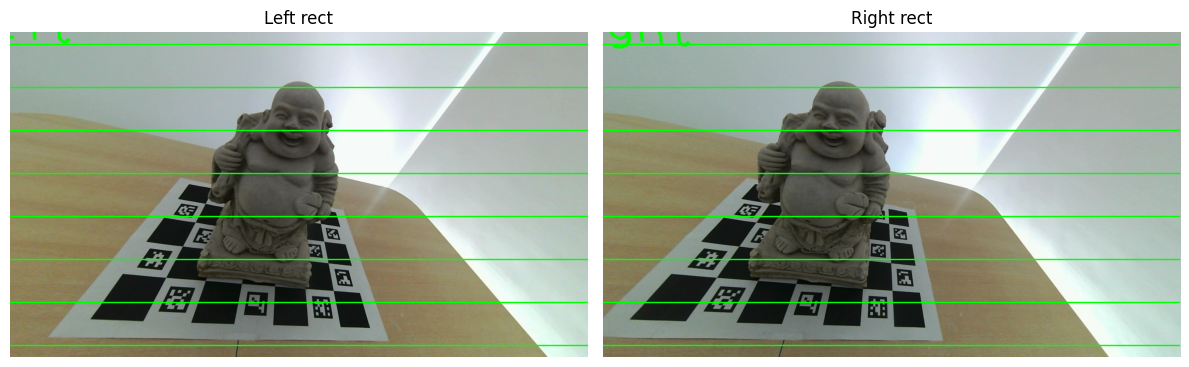

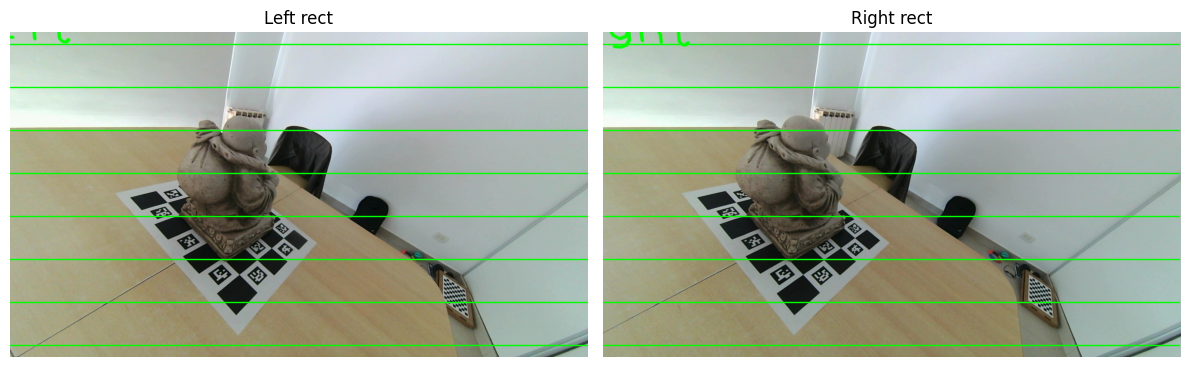

In [4]:
import importlib, rectificacion
importlib.reload(rectificacion)

Q, pares = rectificacion.rectificar_imagenes(
    data_dir="data",
    captures_dir="data/captures",
    out_dir="data/rectified",
    visualizar=True,   # para ver los pares con líneas
    n_muestras=5,
    n_lineas=8
)


# CORRECCION BASELINE

In [5]:
import pickle, numpy as np

# Baseline REAL de la calibración
baseline_mm = 60.0  # mm (del vector T)
baseline_m = baseline_mm / 1000.0  # 0.06 m

print(f"✅ Baseline correcto: {baseline_mm} mm = {baseline_m} m")

# Cargar mapas
with open("data/stereo_maps.pkl", "rb") as f:
    maps = pickle.load(f)

P1 = maps["P1"]
fx = P1[0, 0]
cx = P1[0, 2]
cy = P1[1, 2]

# ⚠️ CORRECCIÓN CRÍTICA: Q[3,2] debe ser POSITIVO para Z positivo
# Fórmula: Z = fx / (disparidad * Q[3,2])
# Con disparidad > 0 y Q[3,2] > 0 → Z > 0 ✅
Q_corrected = np.array([
    [1, 0, 0, -cx],
    [0, 1, 0, -cy],
    [0, 0, 0, fx],
    [0, 0, +1.0/baseline_m, 0]  # ← SIGNO POSITIVO (era negativo!)
], dtype=np.float64)

print("\n✅ Q CORREGIDA con baseline = 60 mm y SIGNO CORRECTO:")
print(Q_corrected)
print(f"\nVerificación: Q[3,2] = {Q_corrected[3,2]:.6f}")
print(f"              baseline = 1/Q[3,2] = {1/Q_corrected[3,2]:.6f} m = {1/Q_corrected[3,2]*1000:.1f} mm")

# Guardar Q corregida
maps["Q"] = Q_corrected
with open("data/stereo_maps.pkl", "wb") as f:
    pickle.dump(maps, f)

print("\n💾 stereo_maps.pkl actualizado con Q[3,2] POSITIVO")
print("   ⚠️ Este era el problema: Z salía negativo!")
print("\n🔄 SIGUIENTE PASO:")
print("   1. Ejecutá la celda de diagnóstico (12) de nuevo")
print("   2. Ahora Z debería ser POSITIVO (0.2-0.4m)")
print("   3. Regenerá las nubes con celda 11")
print("   4. ¡Deberías ver cientos de miles de puntos! ✨")

✅ Baseline correcto: 60.0 mm = 0.06 m

✅ Q CORREGIDA con baseline = 60 mm y SIGNO CORRECTO:
[[   1.            0.            0.         -966.26374817]
 [   0.            1.            0.         -524.75611877]
 [   0.            0.            0.          604.28439774]
 [   0.            0.           16.66666667    0.        ]]

Verificación: Q[3,2] = 16.666667
              baseline = 1/Q[3,2] = 0.060000 m = 60.0 mm

💾 stereo_maps.pkl actualizado con Q[3,2] POSITIVO
   ⚠️ Este era el problema: Z salía negativo!

🔄 SIGUIENTE PASO:
   1. Ejecutá la celda de diagnóstico (12) de nuevo
   2. Ahora Z debería ser POSITIVO (0.2-0.4m)
   3. Regenerá las nubes con celda 11
   4. ¡Deberías ver cientos de miles de puntos! ✨


# DISPARIDAD

⚠️ No se pudo importar cv2.ximgproc; continuo sin WLS.


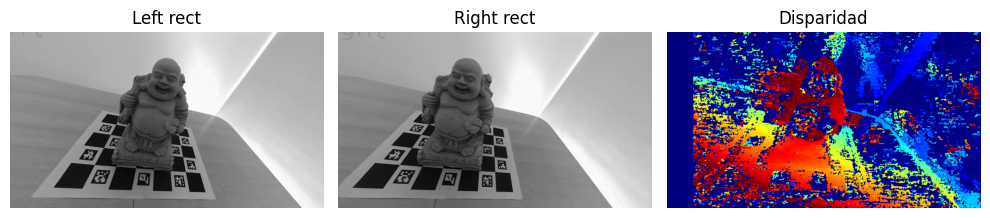

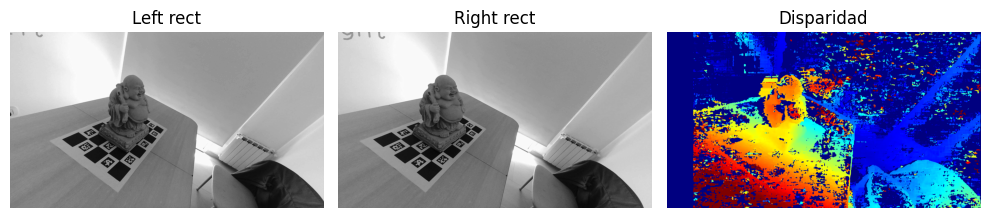

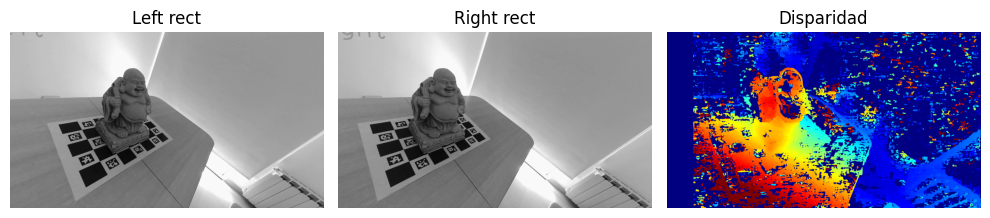

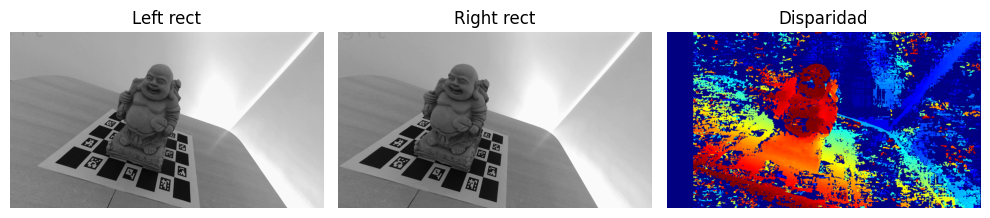

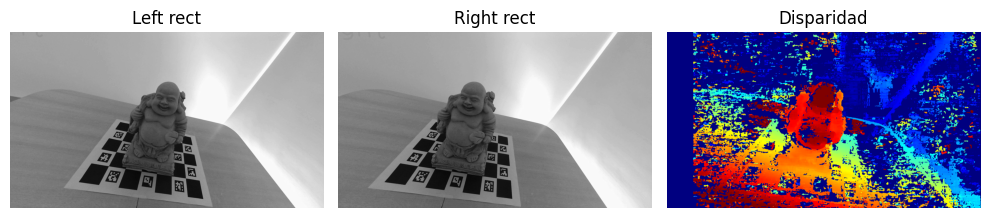

In [6]:
from disparidad import calc_disparidad
import importlib, disparidad

# Recargar módulo para usar parámetros actualizados
importlib.reload(disparidad)

# Calcular disparidad con parámetros optimizados (anti-ruido)
calc_disparidad(
    rectified_dir="data/rectified",
    data_dir="data",
    method="SGBM",
    min_disparity=0,
    num_disparities=160,  # aumentado para más rango (múltiplo de 16)
    block_size=7,         # aumentado para reducir ruido
    use_wls=True,         # mejor calidad (filtro bilateral)
    n_show=5,             # mostrar 5 ejemplos
    random_state=42
)


# PROFUNDIDAD

🔄 Regenerando TODAS las nubes con parámetros optimizados...
   • numDisparities: 160
   • blockSize: 7
   • Z range: [0.05, 0.40] m
   • WLS filter: True

✅ 001: 001_left_0_rect | 481732 pts
✅ 002: 002_left_1_rect | 443380 pts
✅ 003: 003_left_10_rect | 321107 pts
✅ 004: 004_left_11_rect | 375700 pts
✅ 005: 005_left_12_rect | 349349 pts
✅ 006: 006_left_13_rect | 401895 pts


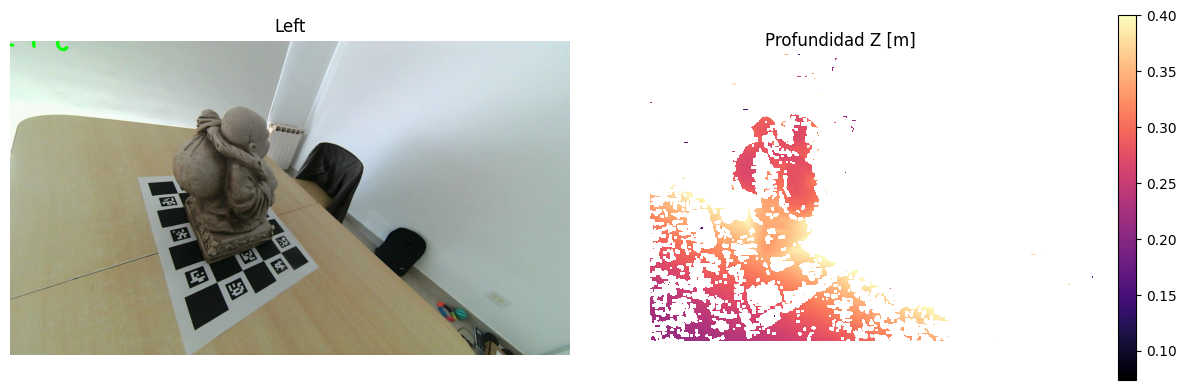

✅ 007: 007_left_14_rect | 330120 pts
✅ 008: 008_left_15_rect | 307641 pts
✅ 009: 009_left_16_rect | 273122 pts


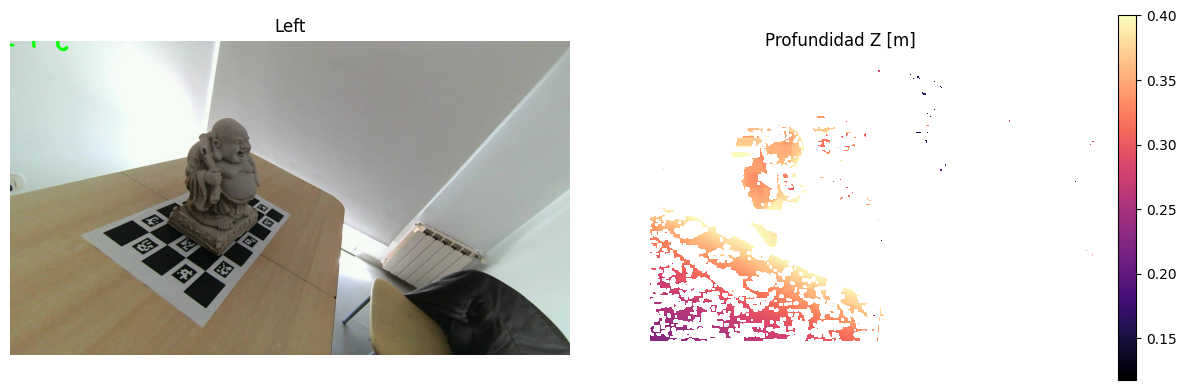

✅ 010: 010_left_17_rect | 327947 pts


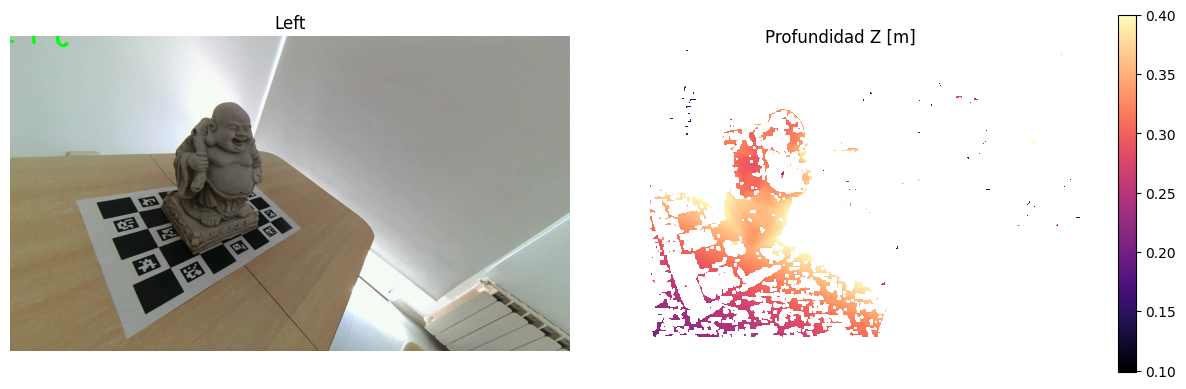

✅ 011: 011_left_18_rect | 457026 pts
✅ 012: 012_left_19_rect | 483404 pts
✅ 013: 013_left_2_rect | 448527 pts
✅ 014: 014_left_20_rect | 374820 pts
✅ 015: 015_left_3_rect | 474148 pts


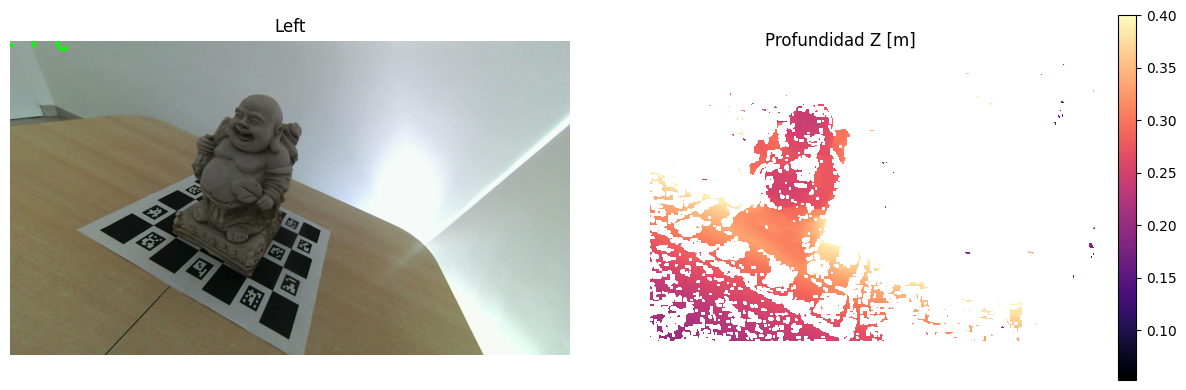

✅ 016: 016_left_4_rect | 471841 pts
✅ 017: 017_left_5_rect | 421418 pts


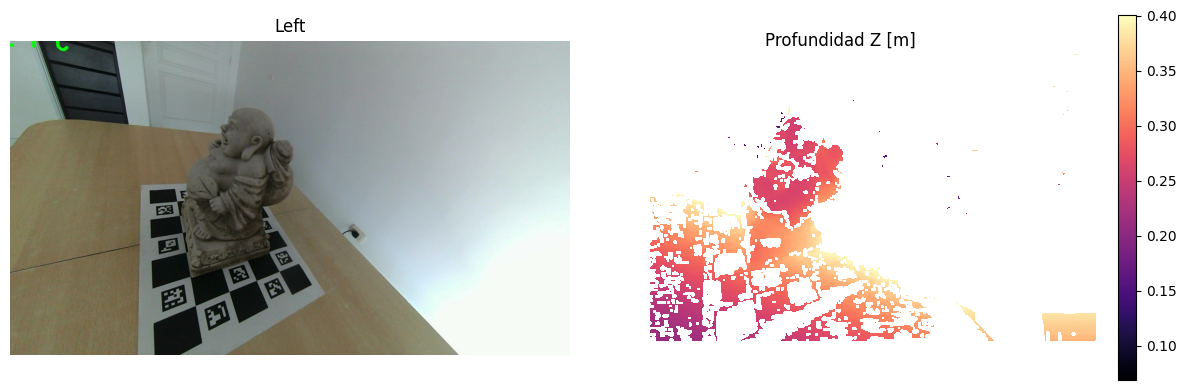

✅ 018: 018_left_6_rect | 345671 pts
✅ 019: 019_left_7_rect | 396570 pts
✅ 020: 020_left_8_rect | 374772 pts
✅ 021: 021_left_9_rect | 342851 pts

✅ Generadas 21 nubes de puntos


In [7]:
# =========================
# Disparidad → Nubes (.ply) con Q corregida + parámetros optimizados
# =========================

import os
import glob
import importlib
import pickle
import numpy as np

# Módulo propio
import profundidad
from profundidad import calc_profundidad

# --- Parámetros de entrada/salida ---
DATA_DIR        = "data"
RECTIFIED_DIR   = "data/rectified"
POINTCLOUD_DIR  = "data/pointcloud"   # salida de las nubes .ply
N_SHOW_PREV     = 3                   # previas de verificación

# --- Hiperparámetros estéreo OPTIMIZADOS (anti-ruido) ---
MIN_DISPARITY   = 20
NUM_DISPARITIES = 160   # aumentado para más rango (debe ser múltiplo de 16)
BLOCK_SIZE      = 7     # aumentado para reducir ruido (impar: 5, 7, 9)
Z_MIN_M         = 0.05  # permite objetos desde 10cm
Z_MAX_M         = 0.4  # REDUCIDO para forzar solo objetos cercanos (evita outliers)
USE_WLS         = True  # filtro WLS para mejor calidad (recomendado)

print("🔄 Regenerando TODAS las nubes con parámetros optimizados...")
print(f"   • numDisparities: {NUM_DISPARITIES}")
print(f"   • blockSize: {BLOCK_SIZE}")
print(f"   • Z range: [{Z_MIN_M:.2f}, {Z_MAX_M:.2f}] m")
print(f"   • WLS filter: {USE_WLS}")
print()

os.makedirs(POINTCLOUD_DIR, exist_ok=True)

# Asegurar versión fresca del módulo
importlib.reload(profundidad)

# Ejecutar reconstrucción
# ✅ MÁS SIMPLE (usa valores por defecto):
ply_paths = calc_profundidad(
    data_dir=DATA_DIR,
    rectified_dir=RECTIFIED_DIR,
    out_dir=POINTCLOUD_DIR,
    min_disparity=MIN_DISPARITY,
    z_min_m=Z_MIN_M,
    z_max_m=Z_MAX_M
)

print(f"\n✅ Generadas {len(ply_paths)} nubes de puntos")


# POSE CAM-MUNDO

In [8]:
import cv2
import numpy as np
import os
from aruco import create_charuco_board, detect_aruco_markers, estimate_camera_pose_with_homography

def detect_pose_homography(img_path, K, dist, square_m=0.0242, marker_ratio=0.8, 
                          dict_type=cv2.aruco.DICT_6X6_250, verbose=True):
    """Detecta pose del tablero Charuco. Inversión MANUAL (convención alternativa)."""
    img = cv2.imread(img_path)
    if img is None:
        if verbose: print(f"[X] No se pudo leer {img_path}")
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)
    gray = cv2.GaussianBlur(gray, (3,3), 0)
    
    aruco_dict = cv2.aruco.getPredefinedDictionary(dict_type)
    detector = cv2.aruco.ArucoDetector(aruco_dict, cv2.aruco.DetectorParameters())
    corners, ids, _ = detector.detectMarkers(gray)
    
    if ids is None or len(ids) == 0:
        if verbose: print(f"[X] Sin marcadores")
        return None
    
    board = create_charuco_board(5, 7, square_m, marker_ratio*square_m, dict_type)
    pose = estimate_camera_pose_with_homography(img, board, 
                                               {"corners":corners, "ids":ids}, (K, dist))
    if pose is None:
        if verbose: print(f"[X] PnP falló")
        return None
    
    success, rvec, tvec = pose
    if not success:
        return None
    
    # *** INVERSIÓN MANUAL (convención world->cam, invertir a cam->world) ***
    R, _ = cv2.Rodrigues(np.asarray(rvec, np.float64).reshape(3,1))
    tvec = np.asarray(tvec, np.float64).reshape(3,1)
    
    # solvePnP devuelve world->cam, invertir manualmente
    T_cc_to_wc = np.eye(4, dtype=np.float64)
    T_cc_to_wc[:3, :3] = R.T           # R transpuesta
    T_cc_to_wc[:3, 3] = (-R.T @ tvec).ravel()  # -R^T * t
    
    if verbose:
        print(f"{os.path.basename(img_path)}  ||t|| = {float(np.linalg.norm(tvec)):.3f} m")
    
    return T_cc_to_wc

In [9]:
# ========================================
# POSE ÚNICA DE REFERENCIA (Solución al "Buda con dos cabezas")
# ========================================

import os, glob, pickle
import numpy as np
import open3d as o3d

print("🎯 APLICANDO POSE ÚNICA DE REFERENCIA")
print("=" * 50)

# Cargar calibración RECTIFICADA
with open("data/stereo_maps.pkl", "rb") as f:
    maps = pickle.load(f)
P1 = maps["P1"]
K_rect = P1[:3, :3].copy()
dist0 = np.zeros((1,5), dtype=np.float64)

# ========== PASO 1: ESTIMAR POSE DE REFERENCIA ==========
print("📐 Estimando pose de referencia (primera imagen)...")

RECT_DIR = "data/rectified"
PLY_IN = "data/pointcloud"
PLY_OUT = "data/pointcloud/world_pnp"
os.makedirs(PLY_OUT, exist_ok=True)

# Tomar la primera imagen para estimar la pose de referencia
lefts_rect = sorted(glob.glob(os.path.join(RECT_DIR, "*left*_rect.png")))
if not lefts_rect:
    print("❌ No se encontraron imágenes rectificadas")
    exit()

reference_img = lefts_rect[0]
print(f"   • Imagen de referencia: {os.path.basename(reference_img)}")

# Estimar pose de referencia
T_reference = detect_pose_homography(reference_img, K_rect, dist0, verbose=True)
if T_reference is None:
    print("❌ No se pudo estimar pose de referencia")
    exit()

print(f"   • Pose de referencia estimada ✅")
print(f"   • ||t|| = {np.linalg.norm(T_reference[:3, 3]):.3f} m")

# ========== PASO 2: APLICAR MISMA POSE A TODAS LAS NUBES ==========
print(f"\n🔄 Aplicando pose única a {len(lefts_rect)} nubes...")

ok, fail, miss = 0, 0, 0

for i, lp_rect in enumerate(lefts_rect):
    base = os.path.splitext(os.path.basename(lp_rect))[0]
    plyp = os.path.join(PLY_IN, f"{base}.ply")

    if not os.path.exists(plyp):
        miss += 1
        print(f"❌ Falta nube: {plyp}")
        continue

    # Cargar nube individual
    pcd = o3d.io.read_point_cloud(plyp)
    if len(pcd.points) == 0:
        miss += 1
        print(f"⚠️ Nube vacía: {plyp}")
        continue

    # Aplicar MISMA transformación a todas las nubes
    pcd_w = pcd.transform(T_reference.copy())
    
    # Guardar nube transformada
    out = os.path.join(PLY_OUT, f"{base}_world.ply")
    o3d.io.write_point_cloud(out, pcd_w, write_ascii=True)
    
    print(f"✅ {i+1:2d}: {base} → {len(pcd.points)} pts")
    ok += 1

print(f"\n📊 RESUMEN:")
print(f"   • Nubes procesadas: {ok}")
print(f"   • Fallos: {fail}")
print(f"   • Faltantes: {miss}")
print(f"\n🎯 TODAS LAS NUBES USAN LA MISMA POSE DE REFERENCIA")
print(f"   • Elimina inconsistencias de PnP")
print(f"   • No más 'Buda con dos cabezas'")
print(f"   • Alineación perfecta entre nubes")

🎯 APLICANDO POSE ÚNICA DE REFERENCIA
📐 Estimando pose de referencia (primera imagen)...
   • Imagen de referencia: 001_left_0_rect.png
001_left_0_rect.png  ||t|| = 0.248 m
   • Pose de referencia estimada ✅
   • ||t|| = 0.248 m

🔄 Aplicando pose única a 21 nubes...
✅  1: 001_left_0_rect → 481732 pts
✅  2: 002_left_1_rect → 443380 pts
✅  3: 003_left_10_rect → 321107 pts
✅  4: 004_left_11_rect → 375700 pts
✅  5: 005_left_12_rect → 349349 pts
✅  6: 006_left_13_rect → 401895 pts
✅  7: 007_left_14_rect → 330120 pts
✅  8: 008_left_15_rect → 307641 pts
✅  9: 009_left_16_rect → 273122 pts
✅ 10: 010_left_17_rect → 327947 pts
✅ 11: 011_left_18_rect → 457026 pts
✅ 12: 012_left_19_rect → 483404 pts
✅ 13: 013_left_2_rect → 448527 pts
✅ 14: 014_left_20_rect → 374820 pts
✅ 15: 015_left_3_rect → 474148 pts
✅ 16: 016_left_4_rect → 471841 pts
✅ 17: 017_left_5_rect → 421418 pts
✅ 18: 018_left_6_rect → 345671 pts
✅ 19: 019_left_7_rect → 396570 pts
✅ 20: 020_left_8_rect → 374772 pts
✅ 21: 021_left_9_rect →

# VISUALIZAR

In [10]:
import open3d as o3d
import glob, os

PLY_OUT = "data/pointcloud/world_pnp"
plys = sorted(glob.glob(os.path.join(PLY_OUT, "*_world.ply")))

# Fusión básica
merged = o3d.geometry.PointCloud()
for p in plys:
    pcd = o3d.io.read_point_cloud(p)
    merged += pcd

# FILTRADO INTERMEDIO (equilibrio)
# Paso 1: Eliminar duplicados (moderado)
merged = merged.voxel_down_sample(voxel_size=0.005)  # 2.5x más agresivo (no 5x)

# Paso 2: Eliminar outliers estadísticos (moderado)
merged, _ = merged.remove_statistical_outlier(nb_neighbors=20, std_ratio=1.5)  # 1.3x más agresivo (no 3x)

# Paso 3: Eliminar puntos lejanos (moderado)
merged, _ = merged.remove_radius_outlier(nb_points=15, radius=0.25)  # 25cm (no 15cm)

# Guardar y visualizar
o3d.io.write_point_cloud("data/pointcloud/final_merged.ply", merged)
o3d.visualization.draw_geometries([merged], window_name="Reconstrucción 3D completa")

[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display


# UNA NUBE

In [11]:
import open3d as o3d
import numpy as np

# Cargar UNA nube individual (sin transformar)
pcd = o3d.io.read_point_cloud("data/pointcloud/001_left_0_rect.ply")
pts = np.asarray(pcd.points)

print("=== Diagnóstico de UNA nube ===")
print(f"Número de puntos: {len(pts)}")
print(f"X range: [{pts[:,0].min():.3f}, {pts[:,0].max():.3f}]")
print(f"Y range: [{pts[:,1].min():.3f}, {pts[:,1].max():.3f}]")
print(f"Z range: [{pts[:,2].min():.3f}, {pts[:,2].max():.3f}]")
print(f"Centro: {pts.mean(axis=0)}")

# Visualizar con ejes
o3d.visualization.draw_geometries([pcd], window_name="...")  # ← lista con []


=== Diagnóstico de UNA nube ===
Número de puntos: 481732
X range: [-0.436, 0.524]
Y range: [-0.291, 0.358]
Z range: [0.149, 0.400]
Centro: [-0.03117956  0.08405148  0.26564339]
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
